In [ ]:
from __future__ import annotations

import importlib
import json
import platform
import warnings
from pathlib import Path

REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "scikit-learn": "sklearn",
    "catboost": "catboost",
    "lightgbm": "lightgbm",
    "joblib": "joblib",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
}
OPTIONAL_PACKAGES = {
    "optuna": "optuna",
}

missing = []
for package_name, import_name in REQUIRED_PACKAGES.items():
    if importlib.util.find_spec(import_name) is None:
        missing.append(package_name)

if missing:
    install_line = "%pip install -U " + " ".join(missing + list(OPTIONAL_PACKAGES))
    print("Missing required packages:", ", ".join(missing))
    print("Install them with:")
    print(install_line)
    raise ImportError("Install the missing packages, restart the kernel, and rerun the notebook.")

optional_missing = [package for package, import_name in OPTIONAL_PACKAGES.items() if importlib.util.find_spec(import_name) is None]
if optional_missing:
    print("Optional tuning packages missing:", ", ".join(optional_missing))
    print("Hyperparameter tuning will be unavailable until you install them:")
    print("%pip install -U " + " ".join(optional_missing))        

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb
import joblib

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")

print("Python:", platform.python_version())
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("LightGBM:", lgb.__version__)

Python: 3.13.7
NumPy: 2.4.4
pandas: 3.0.2
LightGBM: 4.6.0


## 1) Configuration — Global Settings & Hyperparameters


In [ ]:
RANDOM_STATE = 42
PHASE = "enrollment"

TEST_SIZE = 0.2
VALIDATION_SIZE = 0.20

RUN_TUNING = False
N_TRIALS = 50
CV_SPLITS = 3

RUN_PSEUDO_LABELING = True
PSEUDO_LABEL_THRESHOLD = 0.95

USE_CATBOOST_GPU = False
USE_LIGHTGBM_GPU = False
LIGHTGBM_GPU_PLATFORM_ID = 0
LIGHTGBM_GPU_DEVICE_ID = 0

SAVE_ARTIFACT = True

## 2) Data Loading — Reading & Preprocessing the Dataset


In [ ]:
def find_project_paths() -> tuple[Path, Path, Path]:
    cwd = Path.cwd().resolve()
    candidate_paths = [
        cwd / "data" / "academic_success.csv",
        cwd / "research" / "data" / "academic_success.csv",
        cwd.parent / "research" / "data" / "academic_success.csv",
    ]
    for data_path in candidate_paths:
        if data_path.exists():
            research_dir = data_path.parents[1]
            project_root = data_path.parents[2]
            return project_root, research_dir, data_path
    raise FileNotFoundError("Could not find 'academic_success.csv' in expected locations.")

PROJECT_ROOT, RESEARCH_DIR, DATA_PATH = find_project_paths()
PICKLES_DIR = RESEARCH_DIR / "pickles"

RAW_COLUMN_RENAMES = {
    "Daytime/evening attendance\t": "Daytime/evening attendance",
    "Nacionality": "Nationality",
}

df = pd.read_csv(DATA_PATH, sep=";", encoding="utf-8-sig")
df.columns = df.columns.str.replace("\ufeff", "", regex=False).str.strip()
df = df.rename(columns=RAW_COLUMN_RENAMES)

print("Data path:", DATA_PATH)
print ("Data shape:", df.shape)
display(df.head())

Data path: /home/pio/Code/academic_success_web_service/research/data/academic_success.csv
Data shape: (4424, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nationality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 3) EDA — Exploratory Data Analysis & Class Distribution


,Target,count,share
0,Graduate,2209,0.499322
1,Dropout,1421,0.321203
2,Enrolled,794,0.179476


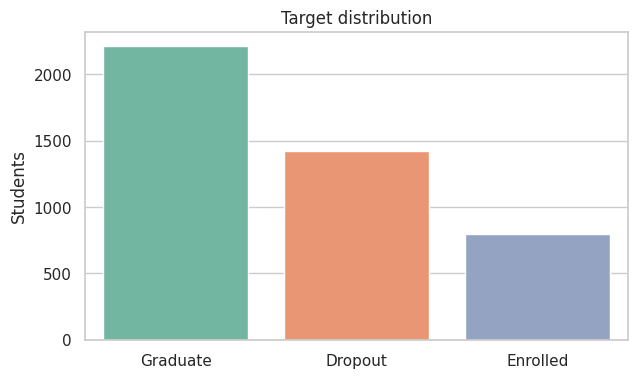

In [ ]:
class_counts = df["Target"].value_counts().rename_axis("Target").reset_index(name="count")
class_counts["share"] = class_counts["count"] / class_counts["count"].sum()
display(class_counts)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=class_counts, x="Target", y="count", ax=ax, palette="Set2", hue="Target", legend=False)
ax.set_title("Target distribution")
ax.set_xlabel("")
ax.set_ylabel("Students")
plt.show()

,count,mean,std,min,25%,50%,75%,max
Previous qualification (grade),4424.0,132.613,13.188,95.00,125.0,133.10,140.00,190.00
Admission grade,4424.0,126.978,14.482,95.00,117.9,126.10,134.80,190.00
Age at enrollment,4424.0,23.265,7.588,17.00,19.0,20.00,25.00,70.00
Unemployment rate,4424.0,11.566,2.664,7.60,9.4,11.10,13.90,16.20
Inflation rate,4424.0,1.228,1.383,-0.80,0.3,1.40,2.60,3.70
GDP,4424.0,0.002,2.270,-4.06,-1.7,0.32,1.79,3.51


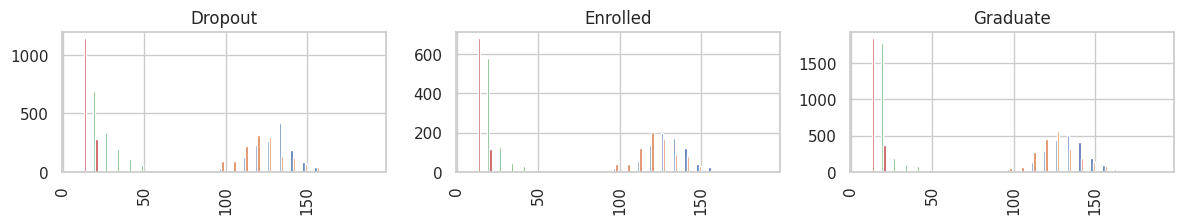

In [ ]:
continuous_features = [
    "Previous qualification (grade)",
    "Admission grade",
    "Age at enrollment",
    "Unemployment rate",
    "Inflation rate",
    "GDP",
]
continuous_features = [col for col in continuous_features if col in df.columns]

display(df[continuous_features].describe().T.round(3))

if continuous_features:
    axes = df[continuous_features + ["Target"]].hist(
        by="Target",
        column=continuous_features[: min(len(continuous_features), 4)],
        figsize=(12, 8),
        bins=25,
        layout=(min(len(continuous_features), 4), 3),
    )
    plt.tight_layout()
    plt.show()

## 4) Feature Engineering — Selecting & Transforming Input Variables

In [ ]:
LABEL_ORDER = ["Dropout", "Graduate"]
UNRESOLVED_LABEL = "Enrolled"
label_to_id = {label: idx for idx, label in enumerate(LABEL_ORDER)}
id_to_label = {idx: label for label, idx in label_to_id.items()}

termilal_df = df[df["Target"].isin(LABEL_ORDER)].copy()
enrolled_df = df[df["Target"] == UNRESOLVED_LABEL].copy()

semester_1_features = [col for col in df.columns if col.startswith("Curricular units 1st sem")]
semester_2_features = [col for col in df.columns if col.startswith("Curricular units 2nd sem")]
base_features = [col for col in df.columns if col not in semester_1_features + semester_2_features + ["Target"]]

FEATURE_PHASES = {
    "enrollment": base_features,
    "semester_1": base_features + semester_1_features,
    "semester_2": base_features + semester_1_features + semester_2_features,
}

if PHASE not in FEATURE_PHASES:
    raise ValueError(f"Invalid phase '{PHASE}'. Valid options are: {', '.join(FEATURE_PHASES.keys())}.")

features = FEATURE_PHASES[PHASE]

categorical_candidates = [
    "Marital status",
    "Application mode",
    "Application order",
    "Course",
    "Daytime/evening attendance",
    "Previous qualification",
    "Nationality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    "Displaced",
    "Educational special needs",
    "Debtor",
    "Tuition fees up to date",
    "Gender",
    "Scholarship holder",
    "International",
]

categorical_features = [col for col in categorical_candidates if col in features]
numeric_features = [col for col in features if col not in categorical_features]

print(f"Phase: {PHASE}")
print(f"Total features: {len(features)}")
print(f"Categorical features: {len(categorical_features)}")
print(f"Numeric features: {len(numeric_features)}")
print("Excluded semester features:", sorted(set(semester_1_features + semester_2_features) - set(features)))

Phase: enrollment
Total features: 24
Categorical features: 18
Numeric features: 6
Excluded semester features: ['Curricular units 1st sem (approved)', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)']


In [ ]:
X_terminal = termilal_df[features].copy()
y_terminal = termilal_df["Target"].map(label_to_id).astype(int)
X_enrolled = enrolled_df[features].copy()

X_train_valid, X_test, y_train_valid, y_test = train_test_split(X_terminal, y_terminal, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_terminal)

valid_fraction_of_train_valid = VALIDATION_SIZE / (1 - TEST_SIZE)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_valid, y_train_valid, test_size=valid_fraction_of_train_valid, random_state=RANDOM_STATE, stratify=y_train_valid)

splt_counts = pd.DataFrame({
    "train": y_train.value_counts().sort_index(),
    "valid": y_valid.value_counts().sort_index(),
    "test": y_test.value_counts().sort_index(),
}).rename(index=id_to_label)
display(splt_counts)

print("Unlabeled enrolled rows available for pseudo-labeling:", len(X_enrolled))

,train,valid,test
Target,,,
Dropout,853,284,284
Graduate,1325,442,442


Unlabeled enrolled rows available for pseudo-labeling: 794


In [ ]:
def make_catboost_frame(X_in: pd.DataFrame) -> pd.DataFrame:
    X_out = X_in.copy()
    for col in categorical_features:
        X_out[col] = X_out[col].astype("category")
    return X_out

def make_lightgbm_frame(X_in: pd.DataFrame) -> pd.DataFrame:
    X_out = X_in.copy()
    for col in categorical_features:
        X_out[col] = X_out[col].astype("category")
    return X_out

X_train_cb = make_catboost_frame(X_train)
X_valid_cb = make_catboost_frame(X_valid)
X_test_cb = make_catboost_frame(X_test)
X_enrolled_cb = make_catboost_frame(X_enrolled)

X_train_lgb = make_lightgbm_frame(X_train)
X_valid_lgb = make_lightgbm_frame(X_valid)
X_test_lgb = make_lightgbm_frame(X_test)
X_enrolled_lgb = make_lightgbm_frame(X_enrolled)

## 5) Metrics — Evaluation Functions & Scoring Utilities


In [ ]:
def align_proba(model, X_model: pd.DataFrame, n_classes: int = len(LABEL_ORDER)) -> np.ndarray:
    proba = np.asarray(model.predict_proba(X_model))
    classes = np.asarray(model.classes_, dtype=int)
    aligned = np.zeros((proba.shape[0], n_classes), dtype=float)
    for source_idx, class_id in enumerate(classes):
        aligned[:, class_id] = proba[:, source_idx]
    return aligned

def weighted_average_proba(probas: list[np.ndarray], weights: list[float] | np.ndarray) -> np.ndarray:
    weights = np.asarray(weights, dtype=float)
    weights = weights / weights.sum()
    stacked = np.stack(probas, axis=0)
    return np.tensordot(weights, stacked, axes=([0], [0]))
    
def evaluate_predictions(
    name: str,
    y_true: pd.Series | np.ndarray,
    y_pred: np.ndarray, 
    y_proba: np.ndarray | None = None,
    show_report: bool = True,
) -> dict[str, float]:
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted"),
        "f1_dropout": f1_score(y_true, y_pred, pos_label=label_to_id["Dropout"]),
        "f1_graduate": f1_score(y_true, y_pred, pos_label=label_to_id["Graduate"]),
        "precision_graduate": precision_score(y_true, y_pred, pos_label=label_to_id["Graduate"]),
        "recall_graduate": recall_score(y_true, y_pred, pos_label=label_to_id["Graduate"]),
    }
    if y_proba is not None:
        metrics["log_loss"] = log_loss(y_true, y_proba, labels=list(range(len(LABEL_ORDER))))
        metrics["roc_auc"] = roc_auc_score(y_true, y_proba[:, label_to_id["Graduate"]])

    print(f"{name} metrics")
    display(pd.Series(metrics).to_frame("score").T.round(4))

    if show_report:
        print(classification_report(y_true, y_pred, target_names=LABEL_ORDER, digits=4))
        cm = confusion_matrix(y_true, y_pred, labels=list(range(len(LABEL_ORDER))))
        fig, ax = plt.subplots(figsize=(5.5, 4.5))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABEL_ORDER, yticklabels=LABEL_ORDER, ax=ax)
        ax.set_title(f"{name} confusion matrix")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        plt.tight_layout()
        plt.show()

    return metrics

def evaluate_model(name: str, model, X_model: pd.DataFrame, y_true: pd.Series | np.ndarray, show_report: bool = True) -> dict[str, float]:
    y_pred = np.asarray(model.predict(X_model)).reshape(-1).astype(int)
    y_proba = align_proba(model, X_model)
    return evaluate_predictions(name, y_true, y_pred, y_proba, show_report=show_report)

def select_blend_weights(cat_proba: np.ndarray, lgb_proba: np.ndarray, y_true: pd.Series | np.ndarray) -> tuple[float, float, pd.DataFrame]:
    weight_rows = []
    for cat_weight in np.linspace(0, 1, 21):
        weights = [cat_weight, 1 - cat_weight]
        blended = weighted_average_proba([cat_proba, lgb_proba], weights)
        pred = blended.argmax(axis=1)
        weight_rows.append({
            "catboost_weight": cat_weight,
            "lightgbm_weight": 1 - cat_weight,
            "f1_macro": f1_score(y_true, pred, average="macro"),
            "balanced_accuracy": balanced_accuracy_score(y_true, pred),
            "roc_auc": roc_auc_score(y_true, blended[:, label_to_id["Graduate"]]),
        })
    weight_search = pd.DataFrame(weight_rows).sort_values(["f1_macro", "balanced_accuracy"], ascending=False)
    best = weight_search.iloc[0]
    return float(best["catboost_weight"]), float(best["lightgbm_weight"]), weight_search
    


## 6) Hyperparameter Tuning — Optuna-based Optimization


In [ ]:
catboost_params = {
    "loss_function": "Logloss",
    "eval_metric": "AUC",
    "iterations": 1000,
    "learning_rate": 0.035,
    "depth": 5,
    "l2_leaf_reg": 6,
    "random_strength": 1.0,
    "auto_class_weights": "Balanced",
    "bootstrap_type": "Bayesian",
    "bagging_temperature": 0.5,
    "random_seed": RANDOM_STATE,
    "allow_writing_files": False,
    "verbose": False,
}

if USE_CATBOOST_GPU:
    catboost_params["task_type"] = "GPU"
    catboost_params["devices"] = "0"

lightgbm_params = {
    "objective": "binary",
    "n_estimators": 900,
    "learning_rate": 0.035,
    "num_leaves": 31,
    "max_depth": -1,
    "min_child_samples": 30,
    "subsample": 0.85,
    "subsample_freq": 1,
    "colsample_bytree": 0.85,
    "reg_alpha": 0.1,
    "reg_lambda": 2.0,
    "class_weight": "balanced",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbosity": -1,
}

if USE_LIGHTGBM_GPU:
    lightgbm_params.update({
        "device_type": "gpu",
        "gpu_platform_id": LIGHTGBM_GPU_PLATFORM_ID,
        "gpu_device_id": LIGHTGBM_GPU_DEVICE_ID,
        "max_bin": 63,
    })

def tune_catboost(X_all: pd.DataFrame, y_all: pd.Series) -> dict:
    import optuna

    cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    def objective(trial: optuna.Trial) -> float:
        params = {
            **catboost_params,
            "iterations": trial.suggest_int("iterations", 500, 1800, step=100),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
            "depth": trial.suggest_int("depth", 3, 8),
            "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 0.5, 20.0, log=True),
            "random_strength": trial.suggest_float("random_strength", 0.0, 4.0),
            "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 2.0),
        }
        scores = []
        for train_idx, valid_idx in cv.split(X_all, y_all):
            X_fold_train = make_catboost_frame(X_all.iloc[train_idx])
            X_fold_valid = make_catboost_frame(X_all.iloc[valid_idx])
            y_fold_train = y_all.iloc[train_idx]
            y_fold_valid = y_all.iloc[valid_idx]

            model = CatBoostClassifier(**params)
            model.fit(X_fold_train, y_fold_train, cat_features=categorical_features, eval_set=(X_fold_valid, y_fold_valid), early_stopping_rounds=100, verbose=False)
            pred = np.asarray(model.predict(X_fold_valid)).reshape(-1).astype(int)
            scores.append(f1_score(y_fold_valid, pred, average="macro"))
        return float(np.mean(scores))
        
    study = optuna.create_study(direction="maximize", study_name=f"catboost_{PHASE}_macro_f1")
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
    print("Best CatBoost macro F1:", study.best_value)
    print("Best CatBoost params:", study.best_params)
    return study.best_params

def tune_lightgbm(X_all: pd.DataFrame, y_all: pd.Series) -> dict:
    import optuna

    cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    def objective(trial: optuna.Trial) -> float:
        params = {
            **lightgbm_params,
            "n_estimators": trial.suggest_int("n_estimators", 400, 1800, step=100),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 15, 95),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
            "subsample": trial.suggest_float("subsample", 0.65, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.65, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 20.0, log=True),
        }
        scores = []
        for train_idx, valid_idx in cv.split(X_all, y_all):
            X_fold_train = make_lightgbm_frame(X_all.iloc[train_idx])
            X_fold_valid = make_lightgbm_frame(X_all.iloc[valid_idx])
            y_fold_train = y_all.iloc[train_idx]
            y_fold_valid = y_all.iloc[valid_idx]

            model = LGBMClassifier(**params)
            model.fit(
                X_fold_train,
                y_fold_train,
                eval_set=[(X_fold_valid, y_fold_valid)],
                eval_metric="binary_logloss",
                categorical_feature=categorical_features,
                callbacks=[lgb.early_stopping(100, verbose=False)],
            )
            pred = np.asarray(model.predict(X_fold_valid)).reshape(-1).astype(int)
            scores.append(f1_score(y_fold_valid, pred, average="macro"))
        return float(np.mean(scores))

    study = optuna.create_study(direction="maximize", study_name=f"lightgbm_{PHASE}_macro_f1")
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
    print("Best LightGBM macro F1:", study.best_value)
    print("Best LightGBM params:", study.best_params)
    return study.best_params


if RUN_TUNING:
    if importlib.util.find_spec("optuna") is None:
        raise ImportError("RUN_TUNING=True requires optuna. Install with `%pip install -U optuna`.")
    tuned_catboost_params = tune_catboost(X_train_valid, y_train_valid)
    tuned_lightgbm_params = tune_lightgbm(X_train_valid, y_train_valid)
    catboost_params.update(tuned_catboost_params)
    lightgbm_params.update(tuned_lightgbm_params)
else:
    print("RUN_TUNING is False; using hand-set, conservative defaults.")

RUN_TUNING is False; using hand-set, conservative defaults.


## 7) Pseudo-Labeling — Semi-Supervised Data Augmentation

### The initial model is trained on true Graduate and Dropout outcomes. Predictions are then made on Enrolled students, and high-confidence results are added to the final training set. Validation and test sets use only true outcomes.

In [ ]:
def fit_catboost(X_fit: pd.DataFrame, y_fit: pd.Series, X_eval: pd.DataFrame, y_eval: pd.Series) -> CatBoostClassifier:
    model = CatBoostClassifier(**catboost_params)
    model.fit(X_fit, y_fit, cat_features=categorical_features, eval_set=(X_eval, y_eval), early_stopping_rounds=120, verbose=False)
    return model

def fit_lightgbm(X_fit: pd.DataFrame, y_fit: pd.Series, X_eval: pd.DataFrame, y_eval: pd.Series) -> LGBMClassifier:
    model = LGBMClassifier(**lightgbm_params)
    model.fit(X_fit, y_fit, eval_set=[(X_eval, y_eval)], eval_metric="binary_logloss", categorical_feature=categorical_features, callbacks=[lgb.early_stopping(120, verbose=False), lgb.log_evaluation(100)])
    return model

pseudo_summary = {
    "enabled": RUN_PSEUDO_LABELING,
    "threshold": PSEUDO_LABEL_THRESHOLD,
    "unresolved_label": UNRESOLVED_LABEL,
    "unresolved_rows" : len(X_enrolled),
    "selected_rows": 0,
    "selected_dropout": 0,
    "selected_graduate": 0,
}

X_train_aug = X_train.copy()
y_train_aug = y_train.copy()

if RUN_PSEUDO_LABELING and len(X_enrolled) > 0:
    cat_model = fit_catboost(X_train_cb, y_train, X_valid_cb, y_valid)
    lgb_model = fit_lightgbm(X_train_lgb, y_train, X_valid_lgb, y_valid)

    cat_proba_valid = align_proba(cat_model, X_valid_cb)
    lgb_proba_valid = align_proba(lgb_model, X_valid_lgb)
    cat_weight, lgb_weight, weight_search = select_blend_weights(cat_proba_valid, lgb_proba_valid, y_valid)

    cat_proba_enrolled = align_proba(cat_model, make_catboost_frame(X_enrolled))
    lgb_proba_enrolled = align_proba(lgb_model, make_lightgbm_frame(X_enrolled))

    print(f"Selected blend weights - CatBoost: {cat_weight:.2f}, LightGBM: {lgb_weight:.2f}")
    display(weight_search.head(10).round(4))

    cat_enrolled_proba = align_proba(cat_model, X_enrolled_cb)

    blended_proba_enrolled = weighted_average_proba([cat_proba_enrolled, lgb_proba_enrolled], [cat_weight, lgb_weight])
    max_proba = blended_proba_enrolled.max(axis=1)
    pseudo_labels = blended_proba_enrolled.argmax(axis=1)

    selected_mask = max_proba >= PSEUDO_LABEL_THRESHOLD
    selected_indices = np.where(selected_mask)[0]
    selected_pseudo_labels = pseudo_labels[selected_mask]

    X_selected = X_enrolled.iloc[selected_indices]
    y_selected = pd.Series(selected_pseudo_labels).map(id_to_label).map(label_to_id).astype(int)

    X_train_aug = pd.concat([X_train_aug, X_selected], axis=0).reset_index(drop=True)
    y_train_aug = pd.concat([y_train_aug, y_selected], axis=0).reset_index(drop=True)

    pseudo_summary.update({
        "selected_rows": len(X_selected),
        "selected_dropout": (y_selected == label_to_id["Dropout"]).sum(),
        "selected_graduate": (y_selected == label_to_id["Graduate"]).sum(),
        "cat_weight": cat_weight,
        "lightgbm_weight": lgb_weight,
    })

## 7) CatBoost Training — Gradient Boosting on Categorical Features


0:	learn: 1.0904066	test: 1.0912601	best: 1.0912601 (0)	total: 52.3ms	remaining: 52.2s
100:	learn: 0.8961298	test: 0.9203525	best: 0.9203525 (100)	total: 997ms	remaining: 8.87s
200:	learn: 0.8515645	test: 0.8999299	best: 0.8999299 (200)	total: 1.71s	remaining: 6.79s
300:	learn: 0.8075234	test: 0.8871339	best: 0.8870092 (298)	total: 2.48s	remaining: 5.76s
400:	learn: 0.7695141	test: 0.8797133	best: 0.8793467 (390)	total: 3.33s	remaining: 4.97s
500:	learn: 0.7424711	test: 0.8774344	best: 0.8774246 (498)	total: 4.17s	remaining: 4.15s
600:	learn: 0.7170355	test: 0.8755084	best: 0.8754688 (599)	total: 5.08s	remaining: 3.37s
700:	learn: 0.6963919	test: 0.8744980	best: 0.8742041 (657)	total: 6.01s	remaining: 2.56s
800:	learn: 0.6764111	test: 0.8740504	best: 0.8738914 (732)	total: 6.86s	remaining: 1.7s
900:	learn: 0.6543939	test: 0.8748765	best: 0.8737118 (814)	total: 7.74s	remaining: 851ms
Stopped by overfitting detector  (120 iterations wait)

bestTest = 0.8737118249
bestIteration = 814

Shr

,accuracy,balanced_accuracy,f1_macro,f1_weighted,log_loss
score,0.6305,0.6083,0.597,0.6416,0.8331


              precision    recall  f1-score   support

     Dropout     0.6705    0.6162    0.6422       284
    Enrolled     0.3632    0.5346    0.4326       159
    Graduate     0.7641    0.6742    0.7163       442

    accuracy                         0.6305       885
   macro avg     0.5993    0.6083    0.5970       885
weighted avg     0.6620    0.6305    0.6416       885



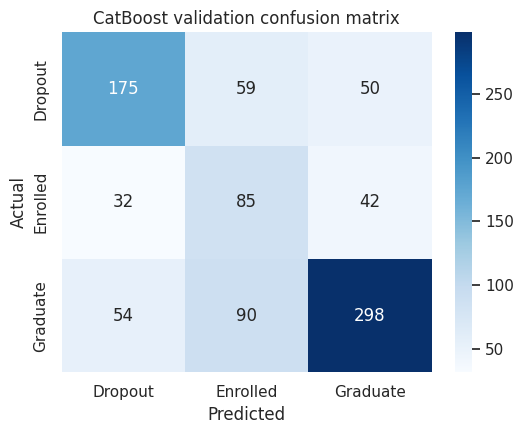

In [ ]:
cat_model = CatBoostClassifier(**catboost_params)
cat_model.fit(X_train_cb, y_train, cat_features=categorical_features, eval_set=(X_valid_cb, y_valid), early_stopping_rounds=120, verbose=100)
cat_valid_metrics = evaluate_model("CatBoost validation", cat_model, X_valid_cb, y_valid, show_report=True)

Training until validation scores don't improve for 120 rounds
[100]	valid_0's multi_logloss: 0.826251
[200]	valid_0's multi_logloss: 0.813973
[300]	valid_0's multi_logloss: 0.82223
Early stopping, best iteration is:
[200]	valid_0's multi_logloss: 0.813973
LightGBM validation metrics


,accuracy,balanced_accuracy,f1_macro,f1_weighted,log_loss
score,0.6508,0.6117,0.6086,0.6533,0.814


              precision    recall  f1-score   support

     Dropout     0.6608    0.6655    0.6632       284
    Enrolled     0.4195    0.4591    0.4384       159
    Graduate     0.7388    0.7104    0.7243       442

    accuracy                         0.6508       885
   macro avg     0.6064    0.6117    0.6086       885
weighted avg     0.6564    0.6508    0.6533       885



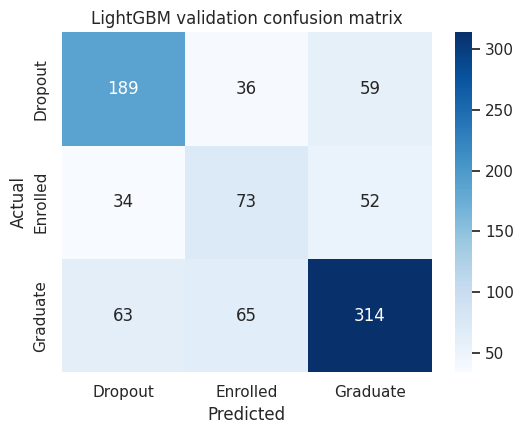

In [ ]:
lgb_model = LGBMClassifier(**lightgbm_params)
lgb_model.fit(
    X_train_lgb,
    y_train,
    eval_set=[(X_valid_lgb, y_valid)],
    eval_metric="binary_logloss",
    categorical_feature=categorical_features,
    callbacks=[lgb.early_stopping(120, verbose=100), lgb.log_evaluation(100)],
)
lgb_valid_metrics = evaluate_model("LightGBM validation", lgb_model, X_valid_lgb, y_valid, show_report=True)

## 8) Ensemble — Soft Voting with CatBoost & LightGBM


,catboost_weight,lightgbm_weight,f1_macro,balanced_accuracy
4,0.20,0.80,0.6104,0.6138
3,0.15,0.85,0.6102,0.6132
2,0.10,0.90,0.6098,0.6128
0,0.00,1.00,0.6086,0.6117
6,0.30,0.70,0.6084,0.6129
12,0.60,0.40,0.6079,0.6160
14,0.70,0.30,0.6076,0.6171
13,0.65,0.35,0.6075,0.6160
7,0.35,0.65,0.6067,0.6127
1,0.05,0.95,0.6067,0.6094


Soft vote validation metrics


,accuracy,balanced_accuracy,f1_macro,f1_weighted,log_loss
score,0.652,0.6138,0.6104,0.6549,0.8081


              precision    recall  f1-score   support

     Dropout     0.6655    0.6655    0.6655       284
    Enrolled     0.4181    0.4654    0.4405       159
    Graduate     0.7406    0.7104    0.7252       442

    accuracy                         0.6520       885
   macro avg     0.6080    0.6138    0.6104       885
weighted avg     0.6585    0.6520    0.6549       885



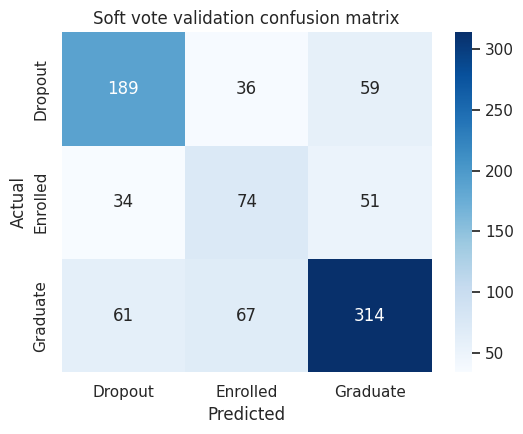

Selected weights: CatBoost=0.20, LightGBM=0.80


In [ ]:
def weighted_average_proba(probas: list[np.ndarray], weights: list[float] | np.ndarray) -> np.ndarray:
    weights = np.asarray(weights, dtype=float)
    weights = weights / weights.sum()
    stacked = np.stack(probas, axis=0)
    return np.tensordot(weights, stacked, axes=(0, 0))


cat_valid_proba = align_proba(cat_model, X_valid_cb)
lgb_valid_proba = align_proba(lgb_model, X_valid_lgb)

weight_rows = []
for cat_weight in np.linspace(0.0, 1.0, 21):
    weights = [cat_weight, 1.0 - cat_weight]
    blended = weighted_average_proba([cat_valid_proba, lgb_valid_proba], weights)
    pred = blended.argmax(axis=1)
    weight_rows.append({
        "catboost_weight": cat_weight,
        "lightgbm_weight": 1.0 - cat_weight,
        "f1_macro": f1_score(y_valid, pred, average="macro"),
        "balanced_accuracy": balanced_accuracy_score(y_valid, pred),
    })

weight_search = pd.DataFrame(weight_rows).sort_values("f1_macro", ascending=False)
display(weight_search.head(10).round(4))

best_cat_weight = float(weight_search.iloc[0]["catboost_weight"])
best_lgb_weight = 1.0 - best_cat_weight
ensemble_valid_proba = weighted_average_proba([cat_valid_proba, lgb_valid_proba], [best_cat_weight, best_lgb_weight])
ensemble_valid_pred = ensemble_valid_proba.argmax(axis=1)
ensemble_valid_metrics = evaluate_predictions(
    "Soft vote validation",
    y_valid,
    ensemble_valid_pred,
    ensemble_valid_proba,
    show_report=True,
)
print(f"Selected weights: CatBoost={best_cat_weight:.2f}, LightGBM={best_lgb_weight:.2f}")


## 9) Feature Importance — Model Interpretability & SHAP Analysis

,catboost_importance,lightgbm_importance
Course,0.1349,0.0662
Tuition fees up to date,0.1131,0.0142
Application mode,0.0738,0.0253
Scholarship holder,0.0690,0.0187
Admission grade,0.0680,0.2154
Father's occupation,0.0631,0.0416
Mother's occupation,0.0573,0.0298
Mother's qualification,0.0509,0.0220
GDP,0.0465,0.0745
Previous qualification (grade),0.0439,0.1505


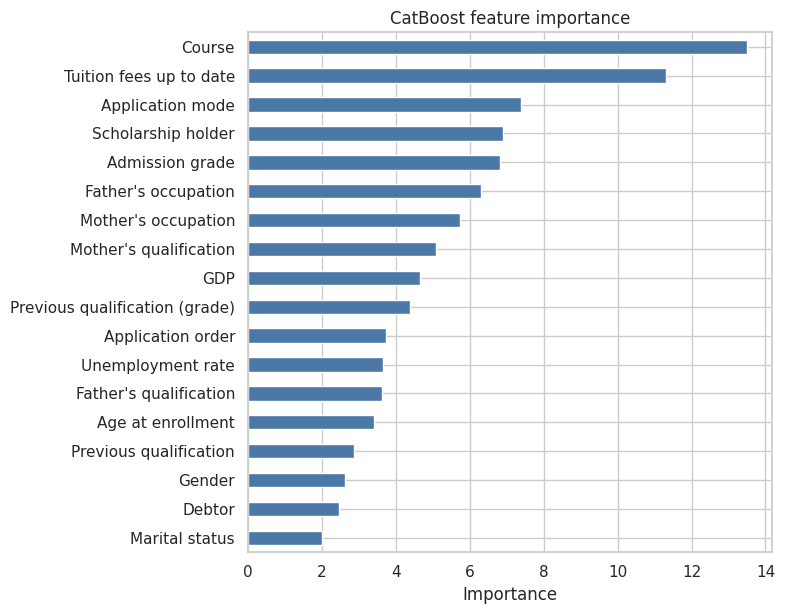

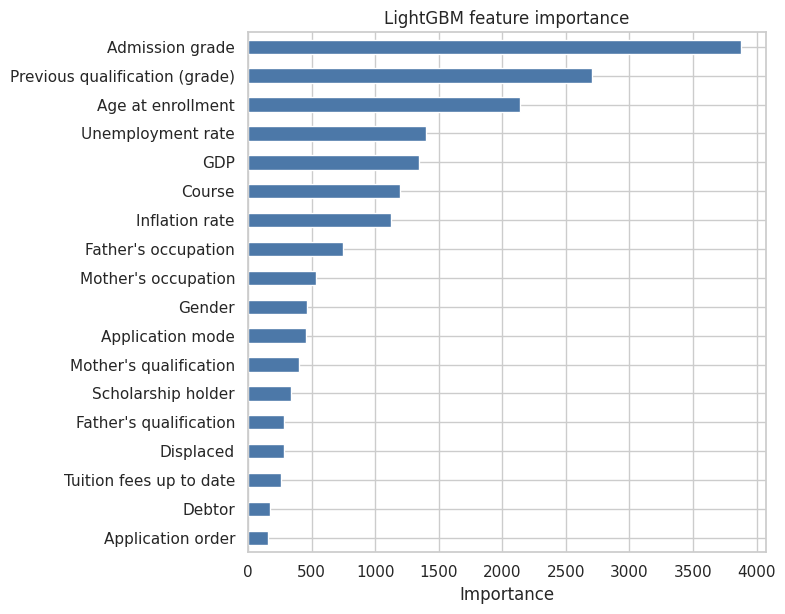

In [ ]:
def plot_importance(importances: pd.Series, title: str, top_n: int = 18) -> None:
    top = importances.sort_values(ascending=False).head(top_n).sort_values()
    fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(top))))
    top.plot(kind="barh", ax=ax, color="#4C78A8")
    ax.set_title(title)
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.show()

cat_importance = pd.Series(cat_model.get_feature_importance(), index=features, name="catboost_importance")
lgb_importance = pd.Series(lgb_model.feature_importances_, index=features, name="lightgbm_importance")

importance_table = pd.concat([
    cat_importance / max(cat_importance.sum(), 1e-12),
    lgb_importance / max(lgb_importance.sum(), 1e-12),
], axis=1).sort_values("catboost_importance", ascending=False)

display(importance_table.head(25).round(4))
plot_importance(cat_importance, "CatBoost feature importance")
plot_importance(lgb_importance, "LightGBM feature importance")

## 10) Final Test — Evaluation on Held-out Test Set


CatBoost test metrics


,accuracy,balanced_accuracy,f1_macro,f1_weighted,log_loss
score,0.5774,0.5532,0.5447,0.5915,0.8573


              precision    recall  f1-score   support

     Dropout     0.6452    0.5634    0.6015       284
    Enrolled     0.3000    0.4717    0.3667       159
    Graduate     0.7132    0.6244    0.6659       442

    accuracy                         0.5774       885
   macro avg     0.5528    0.5532    0.5447       885
weighted avg     0.6171    0.5774    0.5915       885



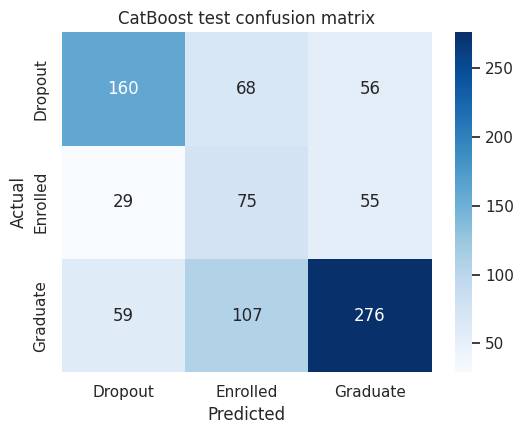

LightGBM test metrics


,accuracy,balanced_accuracy,f1_macro,f1_weighted,log_loss
score,0.5921,0.5455,0.5432,0.598,0.8599


              precision    recall  f1-score   support

     Dropout     0.6263    0.6197    0.6230       284
    Enrolled     0.3016    0.3585    0.3276       159
    Graduate     0.7012    0.6584    0.6791       442

    accuracy                         0.5921       885
   macro avg     0.5430    0.5455    0.5432       885
weighted avg     0.6054    0.5921    0.5980       885



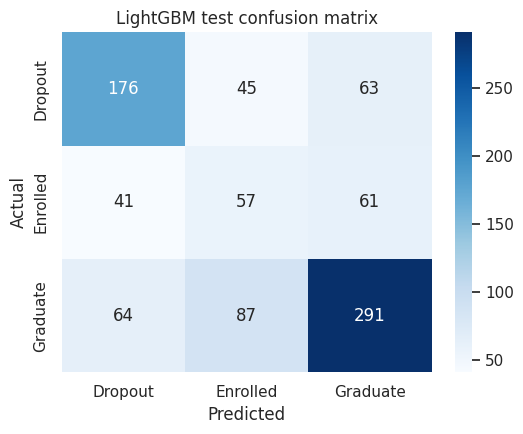

Soft vote test metrics


,accuracy,balanced_accuracy,f1_macro,f1_weighted,log_loss
score,0.591,0.5516,0.5475,0.5983,0.85


              precision    recall  f1-score   support

     Dropout     0.6201    0.6092    0.6146       284
    Enrolled     0.3150    0.3962    0.3510       159
    Graduate     0.7069    0.6493    0.6769       442

    accuracy                         0.5910       885
   macro avg     0.5473    0.5516    0.5475       885
weighted avg     0.6086    0.5910    0.5983       885



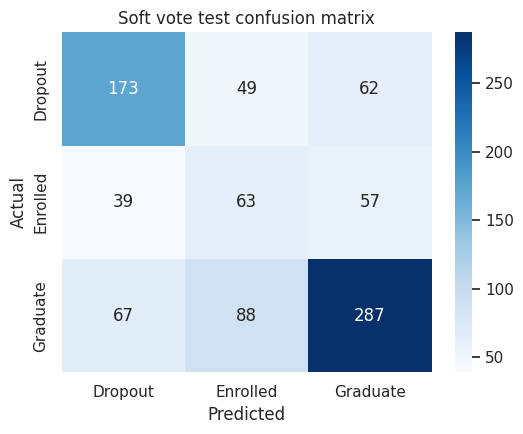

,accuracy,balanced_accuracy,f1_macro,f1_weighted,log_loss
Soft vote valid,0.6520,0.6138,0.6104,0.6549,0.8081
LightGBM valid,0.6508,0.6117,0.6086,0.6533,0.8140
CatBoost valid,0.6305,0.6083,0.5970,0.6416,0.8331
Soft vote test,0.5910,0.5516,0.5475,0.5983,0.8500
CatBoost test,0.5774,0.5532,0.5447,0.5915,0.8573
LightGBM test,0.5921,0.5455,0.5432,0.5980,0.8599


In [ ]:
cat_test_metrics = evaluate_model("CatBoost test", cat_model, X_test_cb, y_test, show_report=True)
lgb_test_metrics = evaluate_model("LightGBM test", lgb_model, X_test_lgb, y_test, show_report=True)

cat_test_proba = align_proba(cat_model, X_test_cb)
lgb_test_proba = align_proba(lgb_model, X_test_lgb)
ensemble_test_proba = weighted_average_proba([cat_test_proba, lgb_test_proba], [best_cat_weight, best_lgb_weight])
ensemble_test_pred = ensemble_test_proba.argmax(axis=1)
ensemble_test_metrics = evaluate_predictions(
    "Soft vote test",
    y_test,
    ensemble_test_pred,
    ensemble_test_proba,
    show_report=True,
)

metrics_table = pd.DataFrame({
    "CatBoost valid": cat_valid_metrics,
    "LightGBM valid": lgb_valid_metrics,
    "Soft vote valid": ensemble_valid_metrics,
    "CatBoost test": cat_test_metrics,
    "LightGBM test": lgb_test_metrics,
    "Soft vote test": ensemble_test_metrics,
}).T

display(metrics_table.round(4).sort_values("f1_macro", ascending=False))


## 11) Model Saving — Serializing the Final Artifact


In [ ]:
bundle = {
    "phase": PHASE,
    "features": features,
    "categorical_features": categorical_features,
    "numeric_features": numeric_features,
    "label_order": LABEL_ORDER,
    "label_to_id": label_to_id,
    "id_to_label": id_to_label,
    "column_renames": RAW_COLUMN_RENAMES,
    "problem_type": "binary_terminal_outcome_with_pseudo_labeling",
    "unresolved_label": UNRESOLVED_LABEL,
    "pseudo_labeling": pseudo_summary,
    "models": {
        "catboost": cat_model,
        "lightgbm": lgb_model,
    },
    "ensemble": {
        "kind": "weighted_probability_average",
        "catboost_weight": best_cat_weight,
        "lightgbm_weight": best_lgb_weight,
    },
    "metrics": metrics_table.to_dict(orient="index"),
    "config": {
        "random_state": RANDOM_STATE,
        "phase": PHASE,
        "run_tuning": RUN_TUNING,
        "use_catboost_gpu": USE_CATBOOST_GPU,
        "use_lightgbm_gpu": USE_LIGHTGBM_GPU,
    },
}

if SAVE_ARTIFACT:
    PICKLES_DIR.mkdir(parents=True, exist_ok=True)
    artifact_path = PICKLES_DIR / "academic_success_enrollment_catboost_lightgbm_bundle.pkl"
    joblib.dump(bundle, artifact_path)
    print(f"Saved model bundle to {artifact_path}")
else:
    print("SAVE_ARTIFACT is False; not saving model bundle.")